In [1]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations_with_replacement

from dadapy.metric_comparisons import MetricComparisons
from dadapy.feature_weighting import FeatureWeighting

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# sample dataset
N = 1000
cov = np.identity(3)
mean = np.zeros(3)
np.random.seed(9)
X = np.random.multivariate_normal(mean=mean, cov=cov, size=(N))

# define spaces A and B by subsets of coordinates
coords1 = [0, 1]
coords2 = [0, 1, 2]

In [ ]:
# define an instance of the FeatureWeighting class
f = FeatureWeighting(coordinates=X[:, coords1])
f_target = FeatureWeighting(coordinates=X[:, coords2])

diff_imbs = []
lambdas = np.logspace(-7, -1, 10)  # uniformly spaced in [1e-7, 1e-1] in log scale (it's the temperature)
for lambd in lambdas:
    diff_imbs.append(f.return_dii(target_data=f_target, lambd=lambd))

/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_2381/1281833669.py:8: UserWarning: maxk option not yet available for the FeatureWeighting class. It will be set to the number of data-1 (1000-1).
  diff_imbs.append(f.return_dii(target_data=f_target, lambd=lambd))


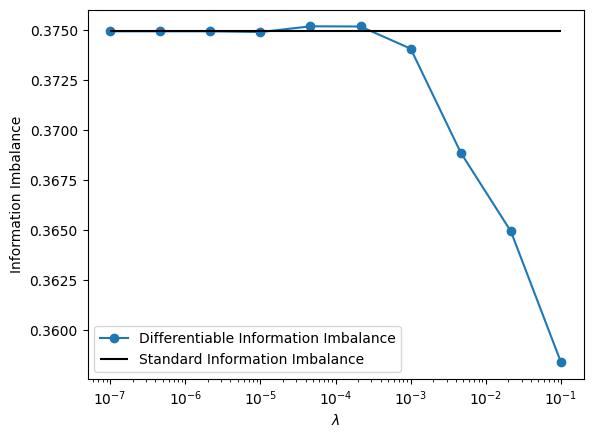

In [4]:
# define an instance of the MetricComparisons class
d = MetricComparisons(X, maxk=N - 1)
imbs = d.return_inf_imb_two_selected_coords(coords1=coords1, coords2=coords2)
plt.plot(lambdas, diff_imbs, "o-", label="Differentiable Information Imbalance")
plt.hlines(
    imbs[0],
    lambdas[0],
    lambdas[-1],
    color="black",
    label="Standard Information Imbalance",
)
plt.xscale("log")
plt.xlabel("$\\lambda$")
plt.ylabel("Information Imbalance")
plt.legend()
plt.show()


In [5]:
# sample datasets
N = 500  # number of points
d = 10  # dimension

cov = np.identity(10)
mean = np.zeros(10)
X = np.random.multivariate_normal(mean=mean, cov=cov, size=(N))  # isotropic Gaussian

weights = np.ones(10) * (0.01**2)
weights[0:5] = [5, 2, 1, 1, 0.5]
X_target = X * weights  # target space B constructed on this anisotropic Gaussian

In [6]:
n_epochs = 50  # number of training epochs

f = FeatureWeighting(coordinates=X)
f_target = FeatureWeighting(coordinates=X_target)
final_weights = f.return_weights_optimize_dii(
    target_data=f_target,
    initial_weights=None,  # (default) automatic weights as inverse std.dev. of features
    n_epochs=n_epochs,
)

/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_2381/3592214572.py:5: UserWarning: maxk option not yet available for the FeatureWeighting class. It will be set to the number of data-1 (500-1).
  final_weights = f.return_weights_optimize_dii(


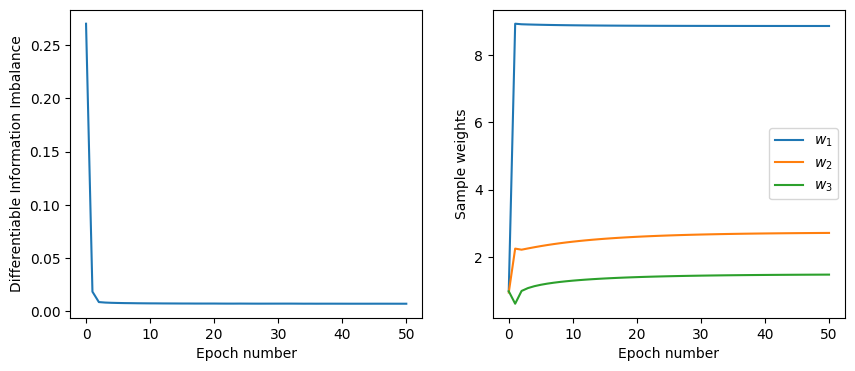

In [7]:
dii_per_epoch = f.history["dii_per_epoch"]
weights_per_epoch = f.history["weights_per_epoch"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(np.arange(n_epochs + 1), dii_per_epoch)
ax2.plot(np.arange(n_epochs + 1), weights_per_epoch[:, 0], label="$w_1$")
ax2.plot(np.arange(n_epochs + 1), weights_per_epoch[:, 1], label="$w_2$")
ax2.plot(np.arange(n_epochs + 1), weights_per_epoch[:, 2], label="$w_3$")

ax1.set(ylabel="Differentiable Information Imbalance", xlabel="Epoch number")
ax2.set(ylabel="Sample weights", xlabel="Epoch number")
ax2.legend()
plt.show()

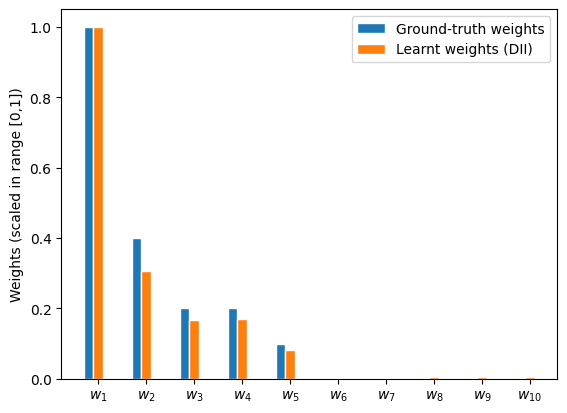

In [8]:
weights_names = (
    "$w_1$",
    "$w_2$",
    "$w_3$",
    "$w_4$",
    "$w_5$",
    "$w_6$",
    "$w_7$",
    "$w_8$",
    "$w_9$",
    "$w_{10}$",
)
weights_grouped = {
    "Ground-truth weights": weights / max(weights),
    "Learnt weights (DII)": final_weights / max(final_weights),
}

x = np.arange(len(weights_names))  # label locations
width = 0.2  # bar widths
multiplier = 0

fig, ax = plt.subplots()
for attribute, measurement in weights_grouped.items():
    offset = width * multiplier
    ax.bar(x + offset, measurement, width, label=attribute, edgecolor="white")
    multiplier += 1

ax.set_ylabel("Weights (scaled in range [0,1])")
ax.set_xticks(x + width, weights_names)
ax.legend()
plt.show()

In [9]:
# create all subsets of 10 elements with cardinality 1 or 2
ncoords = range(10)
monomials_list = []
for degree in [1, 2]:
    monomials_list += list(combinations_with_replacement(ncoords, degree))

# use subsets to construct all possible monomials up to degree 2
X_monomials = np.empty((X.shape[0], len(monomials_list)))
for i_monomial, coords in enumerate(monomials_list):
    monomial = np.prod(X[:, coords], axis=1)
    X_monomials[:, i_monomial] = monomial

In [10]:
# construct the target space B by selecting 10 monomials with different weights
monomials_target = [5, 8, 12, 14, 20, 26, 35, 47, 59, 61]
weights = np.zeros(len(monomials_list))
weights[monomials_target] = [5, 5, 7, 2, 1, 4, 1.5, 1, 3, 6]

coords_names = np.array(
    ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6", "X_7", "X_8", "X_9", "X_{10}"]
)
print("Selected monomials in target space B:")
for monomial_index in monomials_target:
    monomial = monomials_list[monomial_index]
    print(f"\t{coords_names[list(monomial)]} with weight {weights[monomial_index]}")

X_monomials_target = X_monomials * weights

Selected monomials in target space B:
	['X_6'] with weight 5.0
	['X_9'] with weight 5.0
	['X_1' 'X_3'] with weight 7.0
	['X_1' 'X_5'] with weight 2.0
	['X_2' 'X_2'] with weight 1.0
	['X_2' 'X_8'] with weight 4.0
	['X_3' 'X_9'] with weight 1.5
	['X_5' 'X_8'] with weight 1.0
	['X_8' 'X_8'] with weight 3.0
	['X_8' 'X_{10}'] with weight 6.0


In [11]:
n_epochs = 80  # number of training epochs

f = FeatureWeighting(coordinates=X_monomials, verbose=True)
f_target = FeatureWeighting(coordinates=X_monomials_target)

final_imbs, final_weights = f.return_backward_greedy_dii_elimination(
    target_data=f_target,
    initial_weights=None,  # set automatically (default)
    n_epochs=n_epochs,
    learning_rate=None,  # set automatically (default)
)

/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_2381/2287515246.py:6: UserWarning: maxk option not yet available for the FeatureWeighting class. It will be set to the number of data-1 (500-1).
  final_imbs, final_weights = f.return_backward_greedy_dii_elimination(


number of nonzero weights: 65, execution time: 7.02 s.
number of nonzero weights: 64, execution time: 6.89 s.
number of nonzero weights: 63, execution time: 6.73 s.
number of nonzero weights: 62, execution time: 6.72 s.
number of nonzero weights: 61, execution time: 6.81 s.
number of nonzero weights: 60, execution time: 7.00 s.
number of nonzero weights: 59, execution time: 6.65 s.
number of nonzero weights: 58, execution time: 6.35 s.
number of nonzero weights: 57, execution time: 6.16 s.
number of nonzero weights: 56, execution time: 6.30 s.
number of nonzero weights: 55, execution time: 6.05 s.
number of nonzero weights: 54, execution time: 6.26 s.
number of nonzero weights: 53, execution time: 5.98 s.
number of nonzero weights: 52, execution time: 5.85 s.
number of nonzero weights: 51, execution time: 5.73 s.
number of nonzero weights: 50, execution time: 5.86 s.
number of nonzero weights: 49, execution time: 5.79 s.
number of nonzero weights: 48, execution time: 5.56 s.
number of 

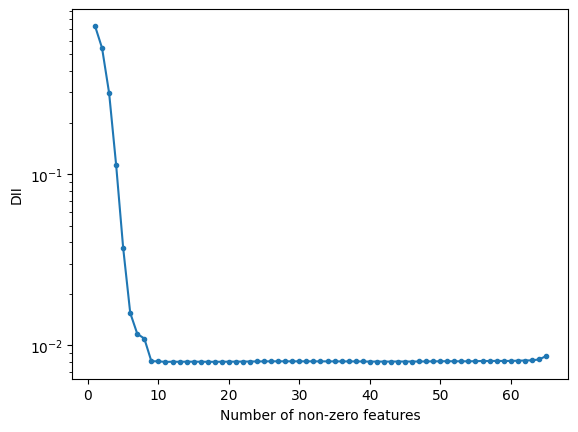

In [12]:
# optimized information imbalance vs number of non-zero features
plt.plot(np.arange(X_monomials.shape[1], 0, -1), final_imbs, ".-")
plt.xlabel("Number of non-zero features")
plt.ylabel("DII")
plt.yscale("log")
plt.show()

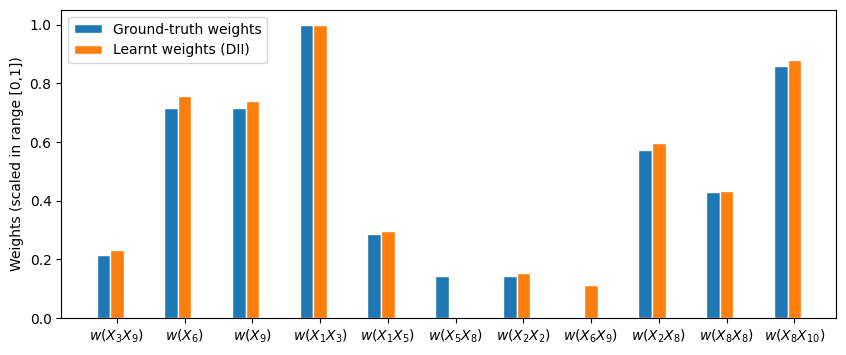

In [13]:
n_subset = 10
monomials_learnt = np.where(final_weights[-n_subset] > 0)[0]
union_set = list(set(monomials_target).union(monomials_learnt))

weights_grouped = {
    "Ground-truth weights": weights[union_set] / max(weights[union_set]),
    "Learnt weights (DII)": final_weights[-n_subset][union_set]
    / max(final_weights[-n_subset][union_set]),
}
weights_names = []
for monomial_index in union_set:
    monomial = monomials_list[monomial_index]
    weights_names.append(f"$w({''.join((coords_names[list(monomial)]))})$")

x = np.arange(len(weights_names))  # label locations
width = 0.2  # bar widths
multiplier = 0
fig, ax = plt.subplots(figsize=(10, 4))
for attribute, measurement in weights_grouped.items():
    offset = width * multiplier
    ax.bar(x + offset, measurement, width, label=attribute, edgecolor="white")
    multiplier += 1
ax.set_ylabel("Weights (scaled in range [0,1])")
ax.set_xticks(x + width, weights_names)
ax.legend()
plt.show()


In [14]:
# create all subsets of 10 elements with cardinality 1 or 2
ncoords = range(10)
monomials_list = []
for degree in [1, 2]:
    monomials_list += list(combinations_with_replacement(ncoords, degree))

# use subsets to construct all possible monomials up to degree 2
X_monomials = np.empty((X.shape[0], len(monomials_list)))
for i_monomial, coords in enumerate(monomials_list):
    monomial = np.prod(X[:, coords], axis=1)
    X_monomials[:, i_monomial] = monomial


In [15]:
# construct space B by selecting 10 monomials with different weights
monomials_target = [5, 8, 12, 14, 20, 26, 35, 47, 59, 61]
weights = np.zeros(len(monomials_list))
weights[monomials_target] = [5, 5, 7, 2, 1, 4, 1.5, 1, 3, 6]

coords_names = np.array(
    ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6", "X_7", "X_8", "X_9", "X_{10}"]
)
print("Selected monomials in target space B:")
for monomial_index in monomials_target:
    monomial = monomials_list[monomial_index]
    print(f"\t{coords_names[list(monomial)]} with weight {weights[monomial_index]}")

X_monomials_target = X_monomials * weights

Selected monomials in target space B:
	['X_6'] with weight 5.0
	['X_9'] with weight 5.0
	['X_1' 'X_3'] with weight 7.0
	['X_1' 'X_5'] with weight 2.0
	['X_2' 'X_2'] with weight 1.0
	['X_2' 'X_8'] with weight 4.0
	['X_3' 'X_9'] with weight 1.5
	['X_5' 'X_8'] with weight 1.0
	['X_8' 'X_8'] with weight 3.0
	['X_8' 'X_{10}'] with weight 6.0


/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_2381/2039632741.py:11: UserWarning: maxk option not yet available for the FeatureWeighting class. It will be set to the number of data-1 (500-1).
  ) = f.return_lasso_optimization_dii_search(


10 l1-penalties to test:
optimization with l1-penalty 1 of strength 0 took: 7.12 s.
optimization with l1-penalty 2 of strength 1e-06 took: 6.93 s.
optimization with l1-penalty 3 of strength 3.162e-06 took: 6.70 s.
optimization with l1-penalty 4 of strength 1e-05 took: 6.83 s.
optimization with l1-penalty 5 of strength 3.162e-05 took: 6.64 s.
optimization with l1-penalty 6 of strength 0.0001 took: 5.90 s.
optimization with l1-penalty 7 of strength 0.0003162 took: 3.93 s.
optimization with l1-penalty 8 of strength 0.001 took: 2.48 s.
optimization with l1-penalty 9 of strength 0.003162 took: 1.85 s.
optimization with l1-penalty 10 of strength 0.01 took: 1.60 s.


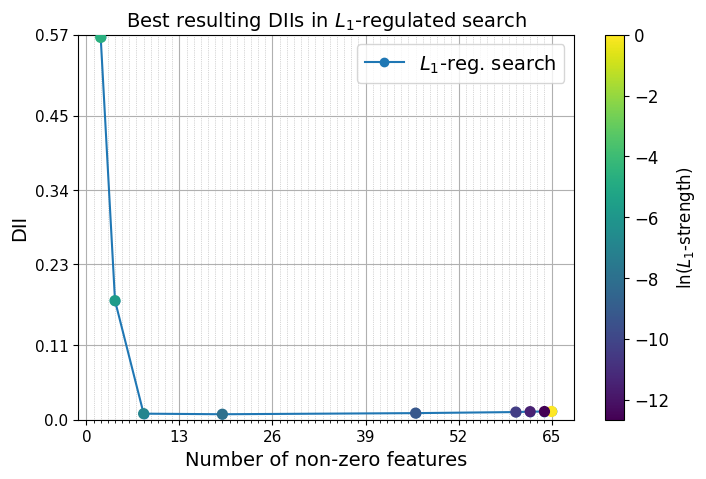

In [16]:
n_epochs = 80  # number of training epochs

f = FeatureWeighting(coordinates=X_monomials, verbose=True)
f_target = FeatureWeighting(coordinates=X_monomials_target)

(
    num_nonzero_features,
    l1_penalties_opt_per_nfeatures,
    dii_opt_per_nfeatures,
    weights_opt_per_nfeatures,
) = f.return_lasso_optimization_dii_search(
    target_data=f_target,
    initial_weights=None,  # (default) set automatically
    n_epochs=n_epochs,
    learning_rate=None,  # (default) set automatically
    refine=False,  # only 10 values of the L1 strength are tested
    plotlasso=True,  # automatically show DII vs number of non-zero features
)

/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_2381/2905363950.py:3: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  monomials_learnt = np.where(weights_opt_per_nfeatures[-9][-n_subset] > 1e-2)[0]


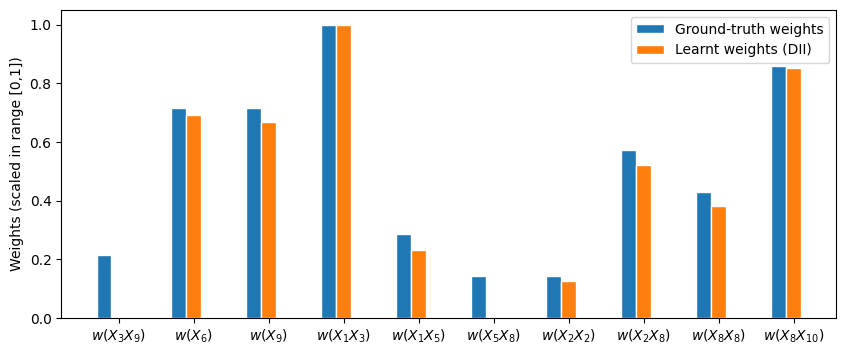

In [17]:
# find number of non-zero features closest to 10 (ground-truth)
n_subset = len(monomials_list) - np.nanargmin(np.abs(10 - num_nonzero_features))
monomials_learnt = np.where(weights_opt_per_nfeatures[-9][-n_subset] > 1e-2)[0]
union_set = list(set(monomials_target).union(monomials_learnt))

weights_grouped = {
    "Ground-truth weights": weights[union_set] / max(weights[union_set]),
    "Learnt weights (DII)": weights_opt_per_nfeatures[-n_subset][union_set]
    / max(weights_opt_per_nfeatures[-n_subset][union_set]),
}
weights_names = []
for monomial_index in union_set:
    monomial = monomials_list[monomial_index]
    weights_names.append(f"$w({''.join((coords_names[list(monomial)]))})$")

x = np.arange(len(weights_names))  # label locations
width = 0.2  # bar widths
multiplier = 0
fig, ax = plt.subplots(figsize=(10, 4))
for attribute, measurement in weights_grouped.items():
    offset = width * multiplier
    ax.bar(x + offset, measurement, width, label=attribute, edgecolor="white")
    multiplier += 1
ax.set_ylabel("Weights (scaled in range [0,1])")
ax.set_xticks(x + width, weights_names)
ax.legend()
plt.show()

In [18]:
# the number of nonzero features in the solutions found with various L1 strengths
num_nonzero_features



array([65., 64., nan, 62., nan, 60., nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, 46., nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, 19., nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan,  8., nan, nan, nan,  4., nan,  2., nan])

In [19]:
# the according L1 strenths for the number of non-zero features as above
l1_penalties_opt_per_nfeatures

array([0.00e+00, 3.16e-06,      nan, 1.00e-05,      nan, 3.16e-05,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan, 1.00e-04,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan, 3.16e-04,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan, 1.00e-03,      nan,      nan,
            nan, 3.16e-03,      nan, 1.00e-02,      nan])

In [20]:
# The according DIIs for the number of non-zero features as above
dii_opt_per_nfeatures

array([0.01, 0.01,  nan, 0.01,  nan, 0.01,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan, 0.01,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan, 0.01,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan, 0.01,  nan,  nan,  nan, 0.18,  nan, 0.57,  nan])

In [21]:

# Feature weights of the optimal solution with 9 non-zero features (see above))
weights_opt_per_nfeatures[-9]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [22]:

# discover which L1 penalties were tested in the search
f.history["l1_penalties"]

array([0.00e+00, 1.00e-06, 3.16e-06, 1.00e-05, 3.16e-05, 1.00e-04,
       3.16e-04, 1.00e-03, 3.16e-03, 1.00e-02])